In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("../data/mockretaildata.csv")

In [7]:
df.head()

,customer_id,age,income,previous_purchases,campaign_response,customer_tenure_days,channel,avg_basket_size,discount,purchase
0,1053,41,28100.0,2,0.106,82,in_store,18.61,15,0
1,2991,48,53100.0,5,0.206,483,in_store,44.66,0,0
2,1789,44,26400.0,4,0.137,1,online,28.27,0,1
3,765,44,43000.0,3,0.109,649,online,38.50,0,1
4,3248,24,17100.0,0,0.000,305,in_store,44.09,0,1


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           5010 non-null   int64  
 1   age                   5010 non-null   int64  
 2   income                4960 non-null   float64
 3   previous_purchases    5010 non-null   int64  
 4   campaign_response     4985 non-null   float64
 5   customer_tenure_days  5010 non-null   int64  
 6   channel               5010 non-null   str    
 7   avg_basket_size       4985 non-null   float64
 8   discount              5010 non-null   int64  
 9   purchase              5010 non-null   int64  
dtypes: float64(3), int64(6), str(1)
memory usage: 426.2 KB


Missing values per column:
Fully duplicated rows: 10
Duplicated customer_id: 10


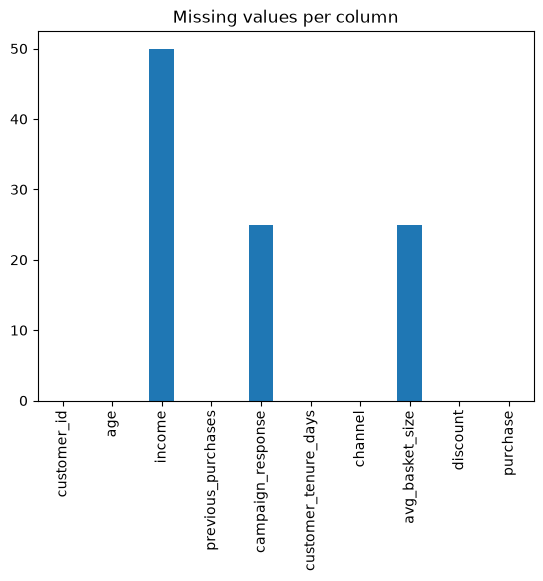

In [18]:
#data check missing values and duplicates
print("Missing values per column:")
df.isnull().sum().plot(kind='bar', title='Missing values per column')
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customer_id:", df.duplicated(subset=['customer_id']).sum())
# Why check duplicatecustomer_id?customer_id is used to uniquely identify each customer. We check for duplicate customer IDs to make sure the same customer is not incorrectly represented multiple times.
#data validation

In [20]:
#data validation 
print("Negative income:", (df['income'] < 0).sum())#Income should not be below 0.
print("Age outside [18, 80]:", ((df['age'] < 18) | (df['age'] > 80)).sum())#Age should be between 18 and 80.
print("Purchase not binary:", (~df['purchase'].isin([0, 1])).sum())#Purchase should only be 0 (No) or 1 (Yes).
print("Discount outside valid set:", (~df['discount'].isin([0,5,10,15,20,25,30])).sum())#Discount should only be 0, 5, 10, 15, 20, 25, 30.

Negative income: 0
Age outside [18, 80]: 0
Purchase not binary: 0
Discount outside valid set: 0
